## Setup

In [1]:
from gut_former.utils.fig_style import apply_style

apply_style(font_family="DejaVu Serif", base_font_size=16)

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from skbio.stats.composition import clr
from skbio.stats.ordination import pcoa

from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore", category=RuntimeWarning, module="skbio")

In [3]:
from gut_former.utils.project_paths import find_data_path, find_figures_path
from gut_former.utils.data_prep import collapse_to_genus

data_path = find_data_path()
figures_path = find_figures_path()
figures_path.mkdir(parents=True, exist_ok=True)

## Read Data

In [4]:
metadata = (
    pd.read_csv(f"{data_path}/metadata_sample.csv", low_memory=False)
    .set_index("sample_id")
    .sort_index()
)

taxonomy = pd.read_csv(f"{data_path}/taxonomy_sample.csv", index_col=0).sort_index()
pathways = pd.read_csv(f"{data_path}/pathways_sample.csv", index_col=0).sort_index()

print(f"metadata: {metadata.shape} | taxonomy: {taxonomy.shape} | pathways: {pathways.shape}")

metadata: (128, 141) | taxonomy: (128, 202) | pathways: (128, 398)


## Signatures (NMF)

In [5]:
def to_relab(x):
    """Normalize each column to sum to 1 (relative contribution)."""
    return x.div(x.sum())


N_FUNC_SIG = 8
N_TAXO_SIG = 5

# --- Functional signatures: H (pathways x signatures), W (samples x signatures) ---
H_func = pd.read_csv(f"{data_path}/H_8_sample_pathways_all.csv", index_col=0).T
H_func.index = H_func.index.str.split(":").str[0]          # short pathway id
H_func = to_relab(H_func)
H_func.columns = H_func.apply(lambda c: " & ".join(c.nlargest(2).index), axis=0)

W_func = pd.read_csv(f"{data_path}/W_train_8_sample_pathways_all.csv", index_col=0)
W_func = to_relab(W_func)
W_func.columns = H_func.columns
W_func["dominant_sig"] = W_func.T.idxmax()
EF_dict = dict(zip(W_func.index, W_func["dominant_sig"]))

# --- Taxonomic signatures: H (genus x signatures), W (samples x signatures) ---
H_taxo = pd.read_csv(f"{data_path}/H_5_sample_taxonomy_healthy.csv", index_col=0).T
H_taxo = to_relab(H_taxo)
H_taxo.columns = list(range(N_TAXO_SIG))                   # 0..4 signature ids

W_taxo = pd.read_csv(f"{data_path}/W_train_5_sample_taxonomy_healthy.csv", index_col=0)
W_taxo = W_taxo[W_taxo.index.isin(W_func.index)]
W_taxo.columns = [f"TS{i + 1}" for i in range(N_TAXO_SIG)]

# --- Signature colormap (Okabe-Ito palette) ---
colors = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#56B4E9", "#7A7A00", "#666666",
]
signatures_cmap = dict(zip(H_func.columns, colors))

# Figure 2A - Functional Signature Top Pathways

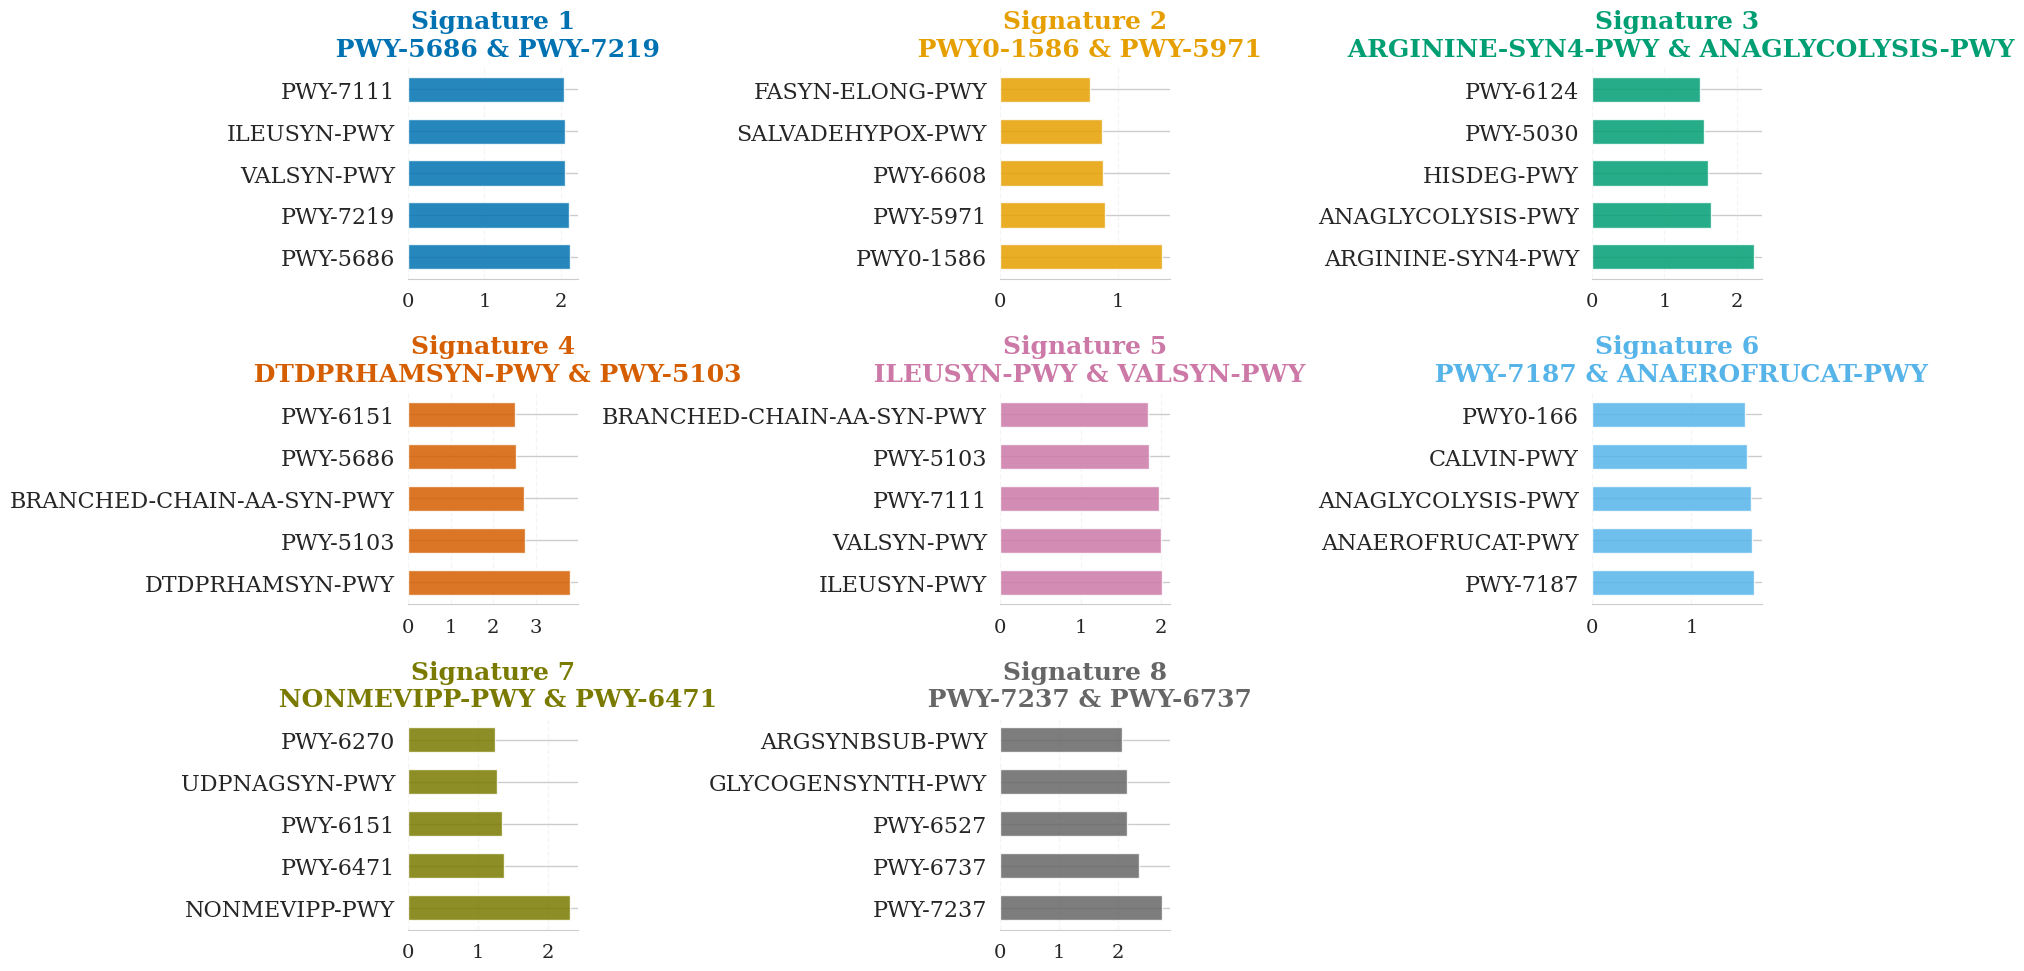

In [6]:
n_cols = 3
n_rows = (N_FUNC_SIG + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for i, sig in enumerate(H_func.columns):
    top_features = H_func.sort_values(by=sig, ascending=False).iloc[:5]
    values = (top_features[sig] * 100).round(2)
    color = signatures_cmap[sig]

    axes[i].barh(range(len(values)), values.values, color=color,
                 edgecolor="white", linewidth=1, alpha=0.85, height=0.6)
    axes[i].set_yticks(range(len(values)))
    axes[i].set_yticklabels(values.index, fontsize=16)
    axes[i].set_title(f"Signature {i + 1}\n {sig}", fontsize=18, fontweight="bold",
                      color=color, pad=8)
    axes[i].tick_params(axis="x", labelsize=14)
    axes[i].xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
    axes[i].grid(axis="x", alpha=0.2, linestyle="--")
    axes[i].set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        axes[i].spines[spine].set_visible(False)
    axes[i].spines["bottom"].set_linewidth(0.8)

for i in range(N_FUNC_SIG, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig2A.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2B - Pathway PCoA by Dominant Signature

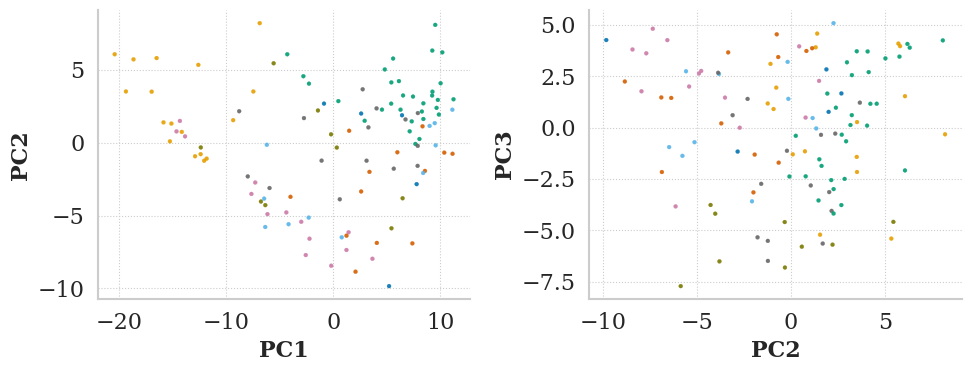

In [7]:
common = pathways.index.intersection(W_func.index)
pathways_clr = clr(pathways.loc[common] + 1e-3)
pcoa_df = pcoa(squareform(pdist(pathways_clr))).samples
pcoa_df.index = common

FSIZE = 16
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(data=pcoa_df, x="PC1", y="PC2", s=8, hue=pcoa_df.index.map(EF_dict),
                palette=signatures_cmap, edgecolor=None, alpha=0.9, ax=axes[0], legend=False)
sns.scatterplot(data=pcoa_df, x="PC2", y="PC3", s=8, hue=pcoa_df.index.map(EF_dict),
                palette=signatures_cmap, edgecolor=None, alpha=0.9, ax=axes[1], legend=False)

axes[0].set_xlabel("PC1", fontsize=FSIZE, weight="bold")
axes[0].set_ylabel("PC2", fontsize=FSIZE, weight="bold")
axes[1].set_xlabel("PC2", fontsize=FSIZE, weight="bold")
axes[1].set_ylabel("PC3", fontsize=FSIZE, weight="bold")

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(axis="both", lw=0.8, linestyle=":", which="major")
    ax.tick_params(axis="both", labelsize=FSIZE)
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig2B.png", dpi=300)
plt.show()

/var/folders/6p/lf2mjrln3bn2l0f1tywc4j580000gn/T/ipykernel_23770/702151706.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


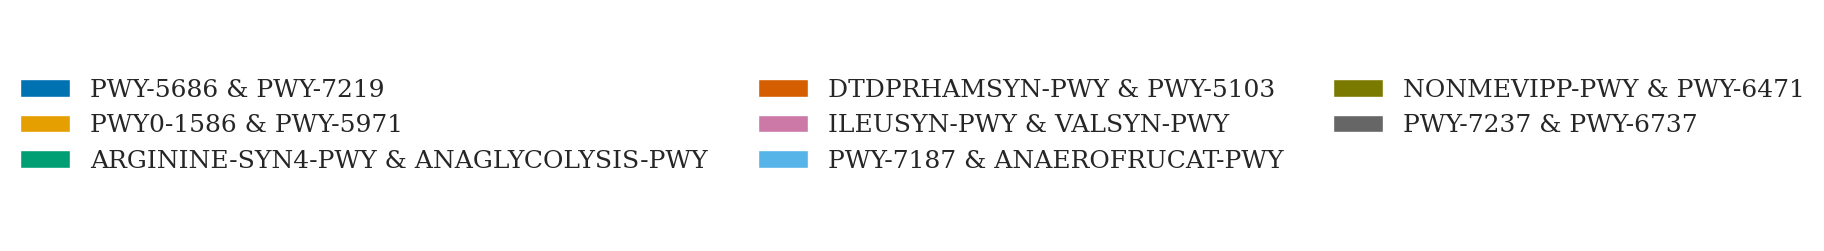

In [8]:
legend_handles = [Patch(facecolor=color, label=sig) for sig, color in signatures_cmap.items()]

fig_leg, ax_leg = plt.subplots(figsize=(7, 3))
ax_leg.axis("off")
ax_leg.legend(handles=legend_handles, loc="center", ncol=3, fontsize=18, frameon=False)

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig2B_legend.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2C - Genus vs Functional Signatures (Healthy)

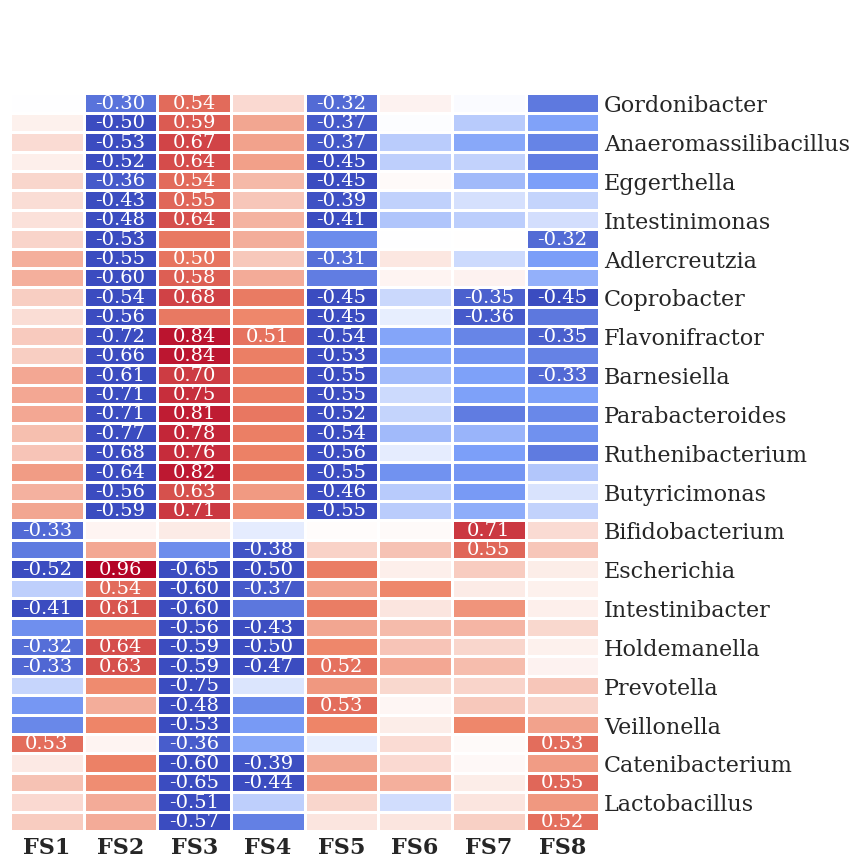

In [9]:
# Healthy subset: correlate genus abundance with functional-signature weights
healthy_idx = metadata.index[metadata["study_condition"] == "control"]

healthy_taxonomy = taxonomy.loc[taxonomy.index.isin(healthy_idx)]
genus = collapse_to_genus(healthy_taxonomy)

W_func_h = W_func.drop(columns="dominant_sig")
W_func_h = W_func_h.loc[W_func_h.index.isin(healthy_idx)]
W_func_h.columns = [f"FS{i + 1}" for i in range(N_FUNC_SIG)]

corrM_full = pd.concat([genus, W_func_h], axis=1).dropna().corr("spearman")
corrM = corrM_full.iloc[:-N_FUNC_SIG, -N_FUNC_SIG:].copy()

# Keep genera with at least one strong correlation
threshold_mask = (corrM > 0.5) | (corrM < -0.5)
corrM = corrM[threshold_mask.any(axis=1)]

annot_matrix = corrM.round(2).astype(object)
for i in range(corrM.shape[0]):
    for j in range(corrM.shape[1]):
        val = corrM.iloc[i, j]
        annot_matrix.iloc[i, j] = f"{val:.2f}" if (val > 0.5 or val < -0.3) else ""

corrM.index = [idx.replace("g__", "") for idx in corrM.index]

base = plt.get_cmap("coolwarm")
better_cmap = LinearSegmentedColormap.from_list(
    "coolwarm_soft", [base(0.0), base(0.2), (1, 1, 1, 1), base(0.8), base(1.0)]
)
norm = TwoSlopeNorm(vmin=-0.4, vcenter=0, vmax=0.9)

g = sns.clustermap(
    corrM, cmap=better_cmap, norm=norm, col_cluster=False,
    annot=annot_matrix.values, fmt="", linewidths=1, linecolor="white",
    figsize=(9, 9), dendrogram_ratio=0.1, cbar_pos=None, annot_kws={"fontsize": 14},
)
g.ax_heatmap.tick_params(axis="both", which="both", length=0)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=16, rotation=0, weight="bold")
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=16, rotation=0)
g.ax_row_dendrogram.set_visible(False)
plt.savefig(f"{figures_path}/Fig2C.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2D - Taxonomic Signature Top Taxa

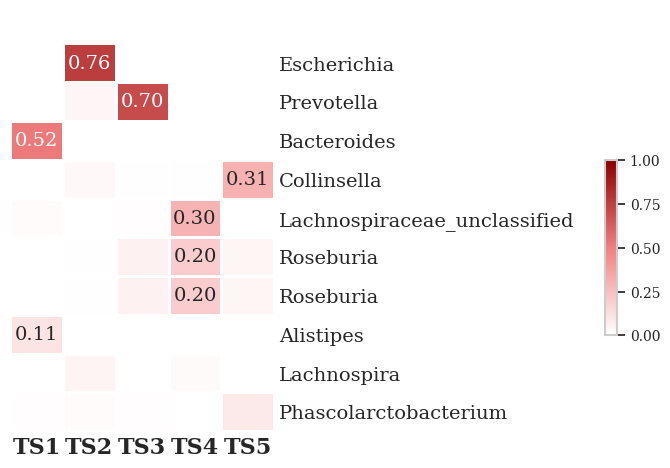

In [10]:
# Top 2 taxa per taxonomic signature
top_taxa = np.concatenate([
    H_taxo.sort_values(by=i, ascending=False).head(2).index for i in range(N_TAXO_SIG)
])

H_taxo_disp = H_taxo.copy()
H_taxo_disp.columns = [f"TS{i + 1}" for i in range(N_TAXO_SIG)]
df = H_taxo_disp.loc[top_taxa]
df.index = [idx.replace("g__", "") for idx in df.index]

annot_matrix = df.round(2).astype(object)
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        val = df.iloc[i, j]
        annot_matrix.iloc[i, j] = f"{val:.2f}" if (pd.notna(val) and val > 0.1) else ""

cmap = LinearSegmentedColormap.from_list("white_to_red", ["white", "lightcoral", "darkred"])

g = sns.clustermap(
    df, cmap=cmap, col_cluster=False, annot=annot_matrix.values, fmt="",
    linewidths=2, linecolor="w", vmin=0, vmax=1,
    figsize=(6, 5), dendrogram_ratio=0.08, cbar_pos=None, annot_kws={"fontsize": 14},
)

cbar_ax = g.fig.add_axes([1.07, 0.3, 0.02, 0.35])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax)
cbar.ax.tick_params(labelsize=10)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])

g.ax_heatmap.tick_params(axis="both", which="both", length=0)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=16, rotation=0, weight="bold")
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=14, rotation=0)
g.ax_row_dendrogram.set_visible(False)
plt.savefig(f"{figures_path}/Fig2D.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2E - Taxonomic vs Functional Signatures

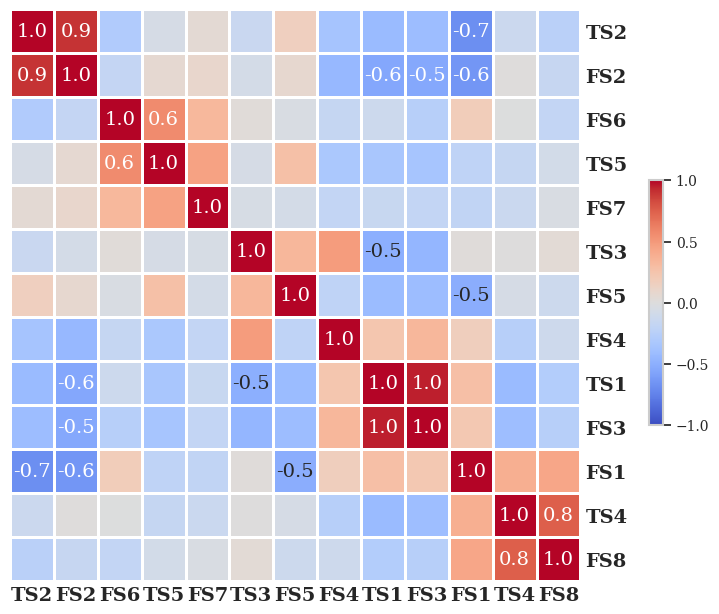

In [11]:
# Correlate taxonomic vs functional signature weights across healthy samples
W_func_h = W_func.drop(columns="dominant_sig")
W_func_h = W_func_h.loc[W_func_h.index.isin(healthy_idx)]
W_func_h.columns = [f"FS{i + 1}" for i in range(N_FUNC_SIG)]

corr = pd.concat([W_taxo, W_func_h], axis=1).dropna().corr()

annot_matrix = corr.round(1).astype(object)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.iloc[i, j]
        annot_matrix.iloc[i, j] = f"{val:.1f}" if (pd.notna(val) and abs(val) > 0.5) else ""

g = sns.clustermap(
    corr, cmap="coolwarm", col_cluster=True, annot=annot_matrix.values, fmt="",
    linewidths=2, linecolor="w", vmin=-1, vmax=1,
    figsize=(7, 7), dendrogram_ratio=0.08, cbar_pos=None, annot_kws={"fontsize": 14},
)

cbar_ax = g.fig.add_axes([1.02, 0.3, 0.02, 0.35])
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=-1, vmax=1))
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax)
cbar.ax.tick_params(labelsize=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

g.ax_heatmap.tick_params(axis="both", which="both", length=0)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=14, rotation=0, weight="bold")
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=14, rotation=0, weight="bold")
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
plt.savefig(f"{figures_path}/Fig2E.png", dpi=300, bbox_inches="tight")
plt.show()